# Coding Test v2 — Latent Representation, Shock Detection & Reliable Time-Series AI

이 노트북은 기존 코딩 테스트의 세 과업을 유지하면서,
첨부 발표자료에서 제시했던 **latent representation 해석, 충격 탐지,
feature influence, ensemble, 반복 실험 안정성** 아이디어를 실제 코드로 발전시킨 버전입니다.

## 원 코딩 테스트 과업
- **Forecasting:** ETTh1
- **Anomaly Detection:** PSM
- **Classification:** UEA / Libras
- 데이터 분석 → 전처리 → Dataset/DataLoader → 모델 → 학습 → 평가 → 시각화
- 하나의 공통 temporal backbone을 과업별 head로 확장

## v2 연구 질문

> 모델이 예측값만 내는 것이 아니라,
> **무엇을 representation으로 학습했고, representation이 언제 급격히 변하며,
> 어떤 입력 feature가 그 변화에 기여하는가?**

이를 위해 다음을 추가합니다.

1. **Latent representation extraction**
   - 각 task의 encoder representation을 직접 추출
   - PCA는 visualization 도구로만 사용하고 인과적 설명으로 해석하지 않음

2. **Feature → latent influence**
   - feature를 하나씩 가리는 perturbation/occlusion 실험
   - latent PC1/PC2가 얼마나 변하는지 정량화

3. **Latent shock score**
   - 단순한 latent 내적 대신 다음 세 신호를 결합
     - reconstruction error
     - latent Mahalanobis distance
     - latent transition velocity
   - 정상 validation 분포만으로 calibration 및 threshold 결정

4. **Reliability**
   - train-only preprocessing
   - baseline 비교
   - PA%K의 올바른 구현
   - optional multi-seed stability test
   - test label을 threshold tuning에 사용하지 않음

5. **Optional real-market case study**
   - KOSPI, USD/KRW, WTI, S&P 500, US 10Y, Gold, VIX
   - benchmark task와 분리된 별도 연구 확장
   - 시장 충격과 representation 변화의 관계를 탐색하되 **인과관계로 단정하지 않음**

## 개인정보 처리

이 노트북에는 이름, 연락처, 학력, 소속, 개인 계정 등
**개인을 식별할 수 있는 정보가 포함되지 않습니다.**

> Google Colab / PyTorch 실행을 기준으로 작성했습니다.

## 0. 기존 답안에서 다시 설계한 이유

기존 노트북에서 확인된 주요 문제는 다음과 같습니다.

- ETTh1 전체 또는 PSM test 자체에 scaler를 fit하는 흐름이 있어 **평가 데이터 통계가 전처리에 유입될 수 있음**.
- 이상치를 z-score로 찾아 0으로 치환하는 전처리는 **PSM에서 실제 이상 신호 자체를 제거할 위험**이 있음.
- `cfg`, dataloader, criterion, model이 세 과업 사이에서 재사용/변경되어 현재 셀이 어떤 과업 상태인지 추적하기 어려움.
- forecasting / anomaly / classification 출력 shape가 다른데 모델 dimension이 하드코딩된 부분이 있음.
- PSM 평가에서 binary anomaly label이 아니라 연속형 배열을 `y_true`로 사용하는 실행 흔적이 있음.
- `PA%K`를 “상위 K개 anomaly score 중 정답 비율”로 계산했는데, 원래 PA%K 정의와 다름.
- 중복 함수/모델 정의가 많아 마지막으로 실행된 정의에 결과가 의존함.

이번 버전은 **task별 state를 명시적으로 분리**하고, 공통 backbone만 공유합니다.

## 발표자료에서 가져온 기술적 문제의식

연구 확장은 첨부 발표자료의 다음 기술적 아이디어를 코드 수준으로 발전시킨 것입니다.

- 시계열 encoder의 hidden/latent representation을 추출해 구조를 관찰
- PCA 2차원 투영을 이용해 representation 변화 탐색
- Autoencoder latent를 이용한 충격 탐지
- 여러 자산/신호의 ensemble
- feature 간 연관성과 영향력의 정량화
- 반복 실험에서 결과 일관성이 떨어지는 문제를 명시적인 validation 대상으로 전환
- 실제 데이터와 도메인 지식을 결합하되 과도한 인과 해석은 피함

발표자료의 개인 식별 정보와 개인 링크는 노트북 설계에 필요하지 않으므로 포함하지 않았습니다.

## 1. 참고한 공식/원 출처

- ETTh1 원 데이터: `zhouhaoyi/ETDataset`
- ETTh1 / PSM benchmark mirror 및 현재 TSLib 데이터 구조: `thuml/Time-Series-Library`
- UEA classification loading: `aeon.datasets.load_classification`
- PA%K 정의: Kim et al., *Towards a Rigorous Evaluation of Time-Series Anomaly Detection*, AAAI 2022

노트북 자체의 모델 구현은 위 저장소의 모델 코드를 복사하지 않고 PyTorch primitive로 새로 작성합니다.

In [1]:
# Colab에서 한 번만 실행
%pip -q install "aeon>=1.4,<1.6" "huggingface_hub>=0.30" "statsmodels>=0.14" "yfinance>=0.2.50"

# yfinance는 optional market case study에서만 사용합니다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 42.1 MB/s eta 0:00:00


In [2]:
import os
import json
import math
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple, Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.covariance import OAS
from sklearn.metrics import silhouette_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from huggingface_hub import hf_hub_download
from aeon.datasets import load_classification

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = True   # 제출 전 충분한 학습은 False 권장

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.set_float32_matmul_precision("high")

ROOT = Path("./coding_test_rebuild")
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("device:", DEVICE)
print("quick_run:", QUICK_RUN)
print("artifact dir:", ARTIFACT_DIR.resolve())

device: cuda
quick_run: True
artifact dir: /content/coding_test_rebuild/artifacts


## 2. Experiment configuration

`QUICK_RUN=True`는 코드와 pipeline correctness를 빠르게 확인하기 위한 설정입니다.  
모델 비교 자체가 목적이라면 `False`로 바꾸고 seed 반복 실험을 권장합니다.

In [3]:
@dataclass
class CommonConfig:
    seed: int = 42
    num_workers: int = 0
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    patience: int = 4

@dataclass
class ForecastConfig:
    seq_len: int = 96
    pred_len: int = 96
    batch_size: int = 64
    epochs: int = 3 if QUICK_RUN else 20
    lr: float = 1e-3
    d_model: int = 64
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.1

@dataclass
class AnomalyConfig:
    win_size: int = 100
    train_step: int = 10 if QUICK_RUN else 5
    eval_step: int = 5 if QUICK_RUN else 1
    batch_size: int = 128
    epochs: int = 3 if QUICK_RUN else 15
    lr: float = 1e-3
    d_model: int = 64
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.1
    threshold_quantile: float = 0.995

@dataclass
class ClassificationConfig:
    batch_size: int = 32
    epochs: int = 8 if QUICK_RUN else 40
    lr: float = 8e-4
    d_model: int = 64
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.15

COMMON = CommonConfig()
F_CFG = ForecastConfig()
A_CFG = AnomalyConfig()
C_CFG = ClassificationConfig()

print(asdict(F_CFG))
print(asdict(A_CFG))
print(asdict(C_CFG))

# 연구 확장 실행 플래그
RUN_LATENT_DIAGNOSTICS = True
RUN_STABILITY_CHECK = False      # 두 번째 seed 재학습 -> 실행시간 증가
RUN_MARKET_CASE_STUDY = False    # yfinance를 사용하는 optional section

print({
    "RUN_LATENT_DIAGNOSTICS": RUN_LATENT_DIAGNOSTICS,
    "RUN_STABILITY_CHECK": RUN_STABILITY_CHECK,
    "RUN_MARKET_CASE_STUDY": RUN_MARKET_CASE_STUDY,
})


{'seq_len': 96, 'pred_len': 96, 'batch_size': 64, 'epochs': 3, 'lr': 0.001, 'd_model': 64, 'n_heads': 4, 'n_layers': 2, 'dropout': 0.1}
{'win_size': 100, 'train_step': 10, 'eval_step': 5, 'batch_size': 128, 'epochs': 3, 'lr': 0.001, 'd_model': 64, 'n_heads': 4, 'n_layers': 2, 'dropout': 0.1, 'threshold_quantile': 0.995}
{'batch_size': 32, 'epochs': 8, 'lr': 0.0008, 'd_model': 64, 'n_heads': 4, 'n_layers': 2, 'dropout': 0.15}
{'RUN_LATENT_DIAGNOSTICS': True, 'RUN_STABILITY_CHECK': False, 'RUN_MARKET_CASE_STUDY': False}


# 3. Data acquisition

다운로드 경로를 한 곳에서 관리합니다.  
ETTh1/PSM은 현재 TSLib benchmark mirror에서 받고, Libras는 aeon loader를 사용합니다.

In [4]:
HF_REPO = "thuml/Time-Series-Library"

def hf_dataset_file(filename: str) -> str:
    return hf_hub_download(
        repo_id=HF_REPO,
        filename=filename,
        repo_type="dataset",
        cache_dir=str(DATA_DIR / "hf_cache"),
    )

def load_etth1_raw() -> pd.DataFrame:
    path = hf_dataset_file("ETT-small/ETTh1.csv")
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df

def load_psm_raw() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_path = hf_dataset_file("PSM/train.csv")
    test_path = hf_dataset_file("PSM/test.csv")
    label_path = hf_dataset_file("PSM/test_label.csv")
    return (
        pd.read_csv(train_path),
        pd.read_csv(test_path),
        pd.read_csv(label_path),
    )

def load_libras_raw():
    X_train, y_train = load_classification("Libras", split="train")
    X_test, y_test = load_classification("Libras", split="test")
    return X_train, y_train, X_test, y_test

## 4. 공통 분석/시각화 함수

EDA는 **데이터를 이해하기 위한 용도**이며, test 통계를 이용해 train 전처리 파라미터를 정하지 않습니다.

In [5]:
def compact_dataframe_report(df: pd.DataFrame, name: str, max_cols: int = 8):
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("duplicate rows:", int(df.duplicated().sum()))
    miss = df.isna().sum()
    print("missing total:", int(miss.sum()))
    if miss.sum() > 0:
        print(miss[miss > 0].sort_values(ascending=False).head(10))
    numeric = df.select_dtypes(include=np.number)
    if not numeric.empty:
        print(numeric.iloc[:, :max_cols].describe().T[["mean","std","min","max"]])

def plot_multivariate(df: pd.DataFrame, cols: List[str], n: int = 1000, title: str = ""):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return
    x = df.iloc[:n]
    plt.figure(figsize=(14, 4))
    for c in cols:
        plt.plot(x[c].to_numpy(), label=c, linewidth=1)
    plt.title(title)
    plt.legend(ncol=min(4, len(cols)))
    plt.tight_layout()
    plt.show()

def plot_history(history: pd.DataFrame, title: str):
    plt.figure(figsize=(7, 3.5))
    for c in history.columns:
        if c != "epoch":
            plt.plot(history["epoch"], history[c], marker="o", label=c)
    plt.xlabel("epoch")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 5. Leakage-safe preprocessing and Dataset classes

### Forecasting
- 시간 순서를 보존하여 70% / 10% / 20% split.
- imputer/scaler는 앞 70% train에만 fit.
- validation/test의 첫 target은 이전 구간의 관측 history를 입력으로 사용할 수 있으나, target 미래값은 입력에 들어가지 않음.

### PSM
- 공식 train의 앞 80%를 model train, 뒤 20%를 validation-normal로 사용.
- imputer/scaler와 anomaly threshold 모두 test label을 보지 않음.
- test label은 마지막 평가에서만 사용.

### Libras
- 공식 train 안에서 stratified train/validation split.
- feature scaler는 inner-train에만 fit.

In [6]:
class ForecastWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, target_start: int, target_end: int, seq_len: int, pred_len: int):
        self.data = np.asarray(data, dtype=np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        first = max(target_start, seq_len)
        last = target_end - pred_len
        if last < first:
            raise ValueError("split is too short for seq_len/pred_len")
        self.target_starts = np.arange(first, last + 1, dtype=np.int64)

    def __len__(self):
        return len(self.target_starts)

    def __getitem__(self, idx):
        t = int(self.target_starts[idx])
        x = self.data[t-self.seq_len:t]
        y = self.data[t:t+self.pred_len]
        return torch.from_numpy(x), torch.from_numpy(y)

class AnomalyWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, win_size: int, step: int):
        self.data = np.asarray(data, dtype=np.float32)
        self.win_size = win_size
        max_start = len(self.data) - win_size
        if max_start < 0:
            raise ValueError("data shorter than win_size")
        starts = list(range(0, max_start + 1, step))
        if starts[-1] != max_start:
            starts.append(max_start)
        self.starts = np.asarray(starts, dtype=np.int64)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = int(self.starts[idx])
        x = self.data[s:s+self.win_size]
        return torch.from_numpy(x), torch.tensor(s, dtype=torch.long)

class ClassificationDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # aeon: [N, C, L] -> model: [N, L, C]
        self.X = np.asarray(X, dtype=np.float32).transpose(0, 2, 1)
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)

def loader(ds, batch_size, shuffle=False):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=COMMON.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

# 6. Unified model: temporal encoder + task head + representation API

공통 backbone:
1. channel projection
2. local temporal convolution
3. sinusoidal positional encoding
4. 직접 구현한 multi-head self-attention block

과업별 head:
- **forecast:** learned future query + cross-attention → `[B, pred_len, C]`
- **anomaly:** timestep reconstruction → `[B, L, C]`
- **classification:** attention pooling → class logits

v2에서는 encoder를 단순한 중간 계산으로 숨기지 않고 `model.encode()` API로 노출합니다.
따라서 **예측 성능과 representation 구조를 분리하여 분석**할 수 있습니다.

PyTorch의 `nn.TransformerEncoder` 같은 완성형 Transformer 블록을 그대로 사용하지 않고
attention 연산을 직접 구성합니다.

In [7]:
def sinusoidal_encoding(length: int, dim: int, device, dtype):
    pos = torch.arange(length, device=device, dtype=dtype).unsqueeze(1)
    half = torch.arange(0, dim, 2, device=device, dtype=dtype)
    div = torch.exp(-math.log(10000.0) * half / dim)
    pe = torch.zeros(length, dim, device=device, dtype=dtype)
    pe[:, 0::2] = torch.sin(pos * div)
    if dim > 1:
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
    return pe

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split(self, x):
        B, L, D = x.shape
        return x.view(B, L, self.n_heads, self.d_head).transpose(1, 2)

    def forward(self, q, kv=None):
        if kv is None:
            kv = q
        Q = self._split(self.q_proj(q))
        K = self._split(self.k_proj(kv))
        V = self._split(self.v_proj(kv))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        z = torch.matmul(attn, V)
        z = z.transpose(1, 2).contiguous().view(q.shape[0], q.shape[1], self.d_model)
        return self.out_proj(z)

class EncoderBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float, ff_mult: int = 4):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model),
            nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.ff(self.norm2(x))
        return x

class TemporalEncoder(nn.Module):
    def __init__(self, in_channels: int, d_model: int, n_heads: int, n_layers: int, dropout: float):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.local_conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.local_norm = nn.LayerNorm(d_model)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.out_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, L, C]
        z = self.input_proj(x)
        local = self.local_conv(z.transpose(1, 2)).transpose(1, 2)
        z = self.local_norm(z + F.gelu(local))
        z = z + sinusoidal_encoding(z.shape[1], z.shape[2], z.device, z.dtype).unsqueeze(0)
        z = self.dropout(z)
        for block in self.blocks:
            z = block(z)
        return self.out_norm(z)

class ForecastHead(nn.Module):
    def __init__(self, d_model: int, n_heads: int, out_channels: int, pred_len: int, dropout: float):
        super().__init__()
        self.pred_len = pred_len
        self.query = nn.Parameter(torch.randn(pred_len, d_model) * 0.02)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 2*d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(2*d_model, d_model),
        )
        self.out = nn.Linear(d_model, out_channels)

    def forward(self, memory):
        B = memory.shape[0]
        q = self.query.unsqueeze(0).expand(B, -1, -1)
        q = q + sinusoidal_encoding(self.pred_len, q.shape[-1], q.device, q.dtype).unsqueeze(0)
        q = q + self.cross_attn(self.norm(q), memory)
        q = q + self.ff(self.norm(q))
        return self.out(q)

class AttentionPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, z):
        w = torch.softmax(self.score(z).squeeze(-1), dim=-1)
        return torch.sum(z * w.unsqueeze(-1), dim=1)

class UnifiedTSModel(nn.Module):
    def __init__(
        self,
        task: str,
        in_channels: int,
        d_model: int = 64,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.1,
        pred_len: Optional[int] = None,
        n_classes: Optional[int] = None,
    ):
        super().__init__()
        self.task = task
        self.encoder = TemporalEncoder(in_channels, d_model, n_heads, n_layers, dropout)

        if task == "forecast":
            if pred_len is None:
                raise ValueError("pred_len required")
            self.head = ForecastHead(d_model, n_heads, in_channels, pred_len, dropout)
        elif task == "anomaly":
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, in_channels),
            )
        elif task == "classification":
            if n_classes is None:
                raise ValueError("n_classes required")
            self.pool = AttentionPool(d_model)
            self.head = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, n_classes),
            )
        else:
            raise ValueError(task)

    def encode_tokens(self, x):
        return self.encoder(x)

    def encode(self, x, pool="mean"):
        z = self.encode_tokens(x)
        if pool == "mean":
            return z.mean(dim=1)
        if pool == "last":
            return z[:, -1]
        if pool == "attention":
            if hasattr(self, "pool"):
                return self.pool(z)
            raise ValueError("attention pooling is only available when the task defines a pool")
        raise ValueError(f"unknown pool={pool}")

    def forward(self, x):
        z = self.encode_tokens(x)
        if self.task == "classification":
            return self.head(self.pool(z))
        return self.head(z)

## 6-1. 모델 shape unit test

실제 대용량 데이터 학습 전에 가장 먼저 interface를 검증합니다.

In [8]:
@torch.no_grad()
def model_shape_smoke_test():
    m_f = UnifiedTSModel("forecast", 7, 32, 4, 1, 0.0, pred_len=24)
    y_f = m_f(torch.randn(3, 96, 7))
    assert y_f.shape == (3, 24, 7)

    m_a = UnifiedTSModel("anomaly", 25, 32, 4, 1, 0.0)
    y_a = m_a(torch.randn(3, 100, 25))
    assert y_a.shape == (3, 100, 25)

    m_c = UnifiedTSModel("classification", 2, 32, 4, 1, 0.0, n_classes=15)
    y_c = m_c(torch.randn(3, 45, 2))
    assert y_c.shape == (3, 15)

    print("✓ model shape smoke test passed")

model_shape_smoke_test()

✓ model shape smoke test passed


# 7. Training utilities

- AdamW
- gradient clipping
- validation loss 기반 early stopping
- 각 epoch history를 CSV로 저장
- best checkpoint 저장

In [9]:
class EarlyStopper:
    def __init__(self, patience=4):
        self.patience = patience
        self.best = float("inf")
        self.count = 0

    def step(self, value):
        improved = value < self.best - 1e-10
        if improved:
            self.best = value
            self.count = 0
        else:
            self.count += 1
        return improved, self.count >= self.patience

def save_json(obj, path):
    path = Path(path)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=lambda x: float(x) if np.isscalar(x) else str(x))

def fit_reconstruction_or_forecast(
    model, train_loader, val_loader, epochs, lr, checkpoint_path, task
):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=COMMON.weight_decay)
    stopper = EarlyStopper(COMMON.patience)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            if task == "forecast":
                x, target = batch
            else:
                x, _ = batch
                target = x

            x = x.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            pred = model(x)
            loss = F.mse_loss(pred, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), COMMON.grad_clip)
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                if task == "forecast":
                    x, target = batch
                else:
                    x, _ = batch
                    target = x
                x = x.to(DEVICE)
                target = target.to(DEVICE)
                pred = model(x)
                val_losses.append(F.mse_loss(pred, target).item())

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(np.mean(val_losses)),
        }
        history.append(row)
        print(row)

        improved, stop = stopper.step(row["val_loss"])
        if improved:
            torch.save(model.state_dict(), checkpoint_path)
        if stop:
            print("early stopping")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history)

def fit_classifier(model, train_loader, val_loader, epochs, lr, checkpoint_path):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=COMMON.weight_decay)
    stopper = EarlyStopper(COMMON.patience)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses, correct, total = [], 0, 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), COMMON.grad_clip)
            opt.step()

            losses.append(loss.item())
            correct += (logits.argmax(-1) == y).sum().item()
            total += y.numel()

        model.eval()
        vlosses, vcorrect, vtotal = [], 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                vlosses.append(F.cross_entropy(logits, y).item())
                vcorrect += (logits.argmax(-1) == y).sum().item()
                vtotal += y.numel()

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "train_acc": correct / total,
            "val_loss": float(np.mean(vlosses)),
            "val_acc": vcorrect / vtotal,
        }
        history.append(row)
        print(row)

        improved, stop = stopper.step(row["val_loss"])
        if improved:
            torch.save(model.state_dict(), checkpoint_path)
        if stop:
            print("early stopping")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history)

## 7-1. Denoising anomaly training + latent analysis utilities

발표자료의 Autoencoder 아이디어를 그대로 identity reconstruction으로 두면
모델이 이상치도 지나치게 잘 복원할 수 있습니다. 따라서 anomaly task에는
**masked/denoising reconstruction**을 사용합니다.

latent를 “그럴듯한 그림”으로만 보지 않기 위해 다음 도구도 구현합니다.

- train latent에 PCA fit → validation/test는 transform만 수행
- feature occlusion → PC 좌표 변화 측정
- OAS covariance 기반 Mahalanobis distance
- latent transition velocity
- validation-normal 기반 robust calibration

In [10]:
def random_mask_input(x, mask_ratio=0.15):
    # Randomly hide individual time-channel observations.
    if mask_ratio <= 0:
        return x
    mask = torch.rand_like(x) < mask_ratio
    return x.masked_fill(mask, 0.0)

def fit_masked_autoencoder(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    checkpoint_path,
    mask_ratio=0.15,
):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=COMMON.weight_decay
    )
    stopper = EarlyStopper(COMMON.patience)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            x_corrupt = random_mask_input(x, mask_ratio)

            opt.zero_grad(set_to_none=True)
            rec = model(x_corrupt)
            loss = F.mse_loss(rec, x)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), COMMON.grad_clip)
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                rec = model(x)
                val_losses.append(F.mse_loss(rec, x).item())

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(np.mean(val_losses)),
        }
        history.append(row)
        print(row)

        improved, stop = stopper.step(row["val_loss"])
        if improved:
            torch.save(model.state_dict(), checkpoint_path)
        if stop:
            print("early stopping")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history)

@torch.no_grad()
def extract_embeddings(model, data_loader):
    # Returns embeddings and the second item from the loader in loader order.
    model.eval()
    embs, aux = [], []

    for x, y in data_loader:
        x = x.to(DEVICE)
        z = model.encode(x, pool="mean")
        embs.append(z.cpu().numpy())
        aux.append(y.numpy())

    return np.concatenate(embs), np.concatenate(aux)

def fit_pca_train_only(train_embeddings, n_components=2):
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(train_embeddings)
    return pca

def robust_location_scale(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float64)
    center = np.median(x)
    mad = np.median(np.abs(x - center))
    scale = max(1.4826 * mad, eps)
    return center, scale

def robust_standardize(x, center, scale):
    return (np.asarray(x, dtype=np.float64) - center) / scale

def aggregate_window_scalar_scores(starts, scores, series_length, win_size):
    total = np.zeros(series_length, dtype=np.float64)
    count = np.zeros(series_length, dtype=np.float64)

    for s, score in zip(np.asarray(starts).astype(int), np.asarray(scores)):
        e = min(s + win_size, series_length)
        total[s:e] += float(score)
        count[s:e] += 1.0

    covered = count > 0
    out = np.zeros(series_length, dtype=np.float64)
    out[covered] = total[covered] / count[covered]
    if (~covered).any():
        out[~covered] = np.median(out[covered])
    return out

def mahalanobis_scores(embeddings, mean, precision):
    d = embeddings - mean[None, :]
    q = np.einsum("bi,ij,bj->b", d, precision, d)
    return np.sqrt(np.maximum(q, 0.0))

def latent_velocity(embeddings):
    v = np.zeros(len(embeddings), dtype=np.float64)
    if len(embeddings) > 1:
        v[1:] = np.linalg.norm(np.diff(embeddings, axis=0), axis=1)
        v[0] = v[1]
    return v

def top_fraction_jaccard(a, b, frac=0.01):
    a = np.asarray(a)
    b = np.asarray(b)
    k = max(1, int(round(len(a) * frac)))
    ia = set(np.argpartition(a, -k)[-k:])
    ib = set(np.argpartition(b, -k)[-k:])
    return len(ia & ib) / max(1, len(ia | ib))

def score_stability_report(score_a, score_b, top_frac=0.01):
    score_a = np.asarray(score_a)
    score_b = np.asarray(score_b)
    return {
        "pearson": float(np.corrcoef(score_a, score_b)[0, 1]),
        "top_jaccard": float(top_fraction_jaccard(score_a, score_b, top_frac)),
        "top_fraction": float(top_frac),
    }

# 8. Task A — ETTh1 forecasting

ETTh1.csv:   0%|          | 0.00/2.59M [00:00<?, ?B/s]


===== ETTh1 raw =====
shape: (17420, 8)
duplicate rows: 0
missing total: 0
           mean       std        min        max
HUFL   7.375141  7.067744 -22.705999  23.643999
HULL   2.242242  2.042342  -4.756000  10.114000
MUFL   4.300239  6.826978 -25.087999  17.341000
MULL   0.881568  1.809293  -5.934000   7.747000
LUFL   3.066062  1.164506  -1.188000   8.498000
LULL   0.856932  0.599552  -1.371000   3.046000
OT    13.324672  8.566946  -4.080000  46.007000


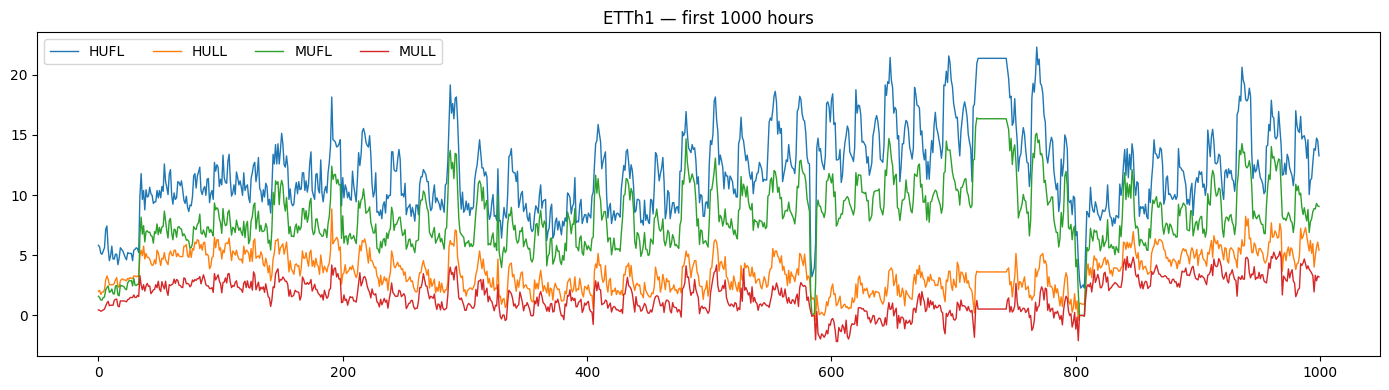

features: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
windows: 12003 1647 3389
input/target: torch.Size([64, 96, 7]) torch.Size([64, 96, 7])


In [11]:
etth1 = load_etth1_raw()
compact_dataframe_report(etth1, "ETTh1 raw")

value_cols = [c for c in etth1.columns if c != "date"]
plot_multivariate(etth1, value_cols[:4], n=1000, title="ETTh1 — first 1000 hours")

n = len(etth1)
train_end = int(n * 0.70)
val_end = int(n * 0.80)

raw_values = etth1[value_cols].to_numpy(dtype=np.float64)

f_imputer = SimpleImputer(strategy="median")
f_scaler = StandardScaler()

train_values = f_imputer.fit_transform(raw_values[:train_end])
f_scaler.fit(train_values)

all_imputed = f_imputer.transform(raw_values)
all_scaled = f_scaler.transform(all_imputed).astype(np.float32)

f_train_ds = ForecastWindowDataset(all_scaled, 0, train_end, F_CFG.seq_len, F_CFG.pred_len)
f_val_ds = ForecastWindowDataset(all_scaled, train_end, val_end, F_CFG.seq_len, F_CFG.pred_len)
f_test_ds = ForecastWindowDataset(all_scaled, val_end, n, F_CFG.seq_len, F_CFG.pred_len)

f_train_loader = loader(f_train_ds, F_CFG.batch_size, shuffle=True)
f_val_loader = loader(f_val_ds, F_CFG.batch_size)
f_test_loader = loader(f_test_ds, F_CFG.batch_size)

print("features:", value_cols)
print("windows:", len(f_train_ds), len(f_val_ds), len(f_test_ds))
print("input/target:", next(iter(f_train_loader))[0].shape, next(iter(f_train_loader))[1].shape)

{'epoch': 1, 'train_loss': 0.5415320455076846, 'val_loss': 0.517153860284732}
{'epoch': 2, 'train_loss': 0.34507471846139176, 'val_loss': 0.5158614080685836}
{'epoch': 3, 'train_loss': 0.2864430344643745, 'val_loss': 0.6484731263839282}


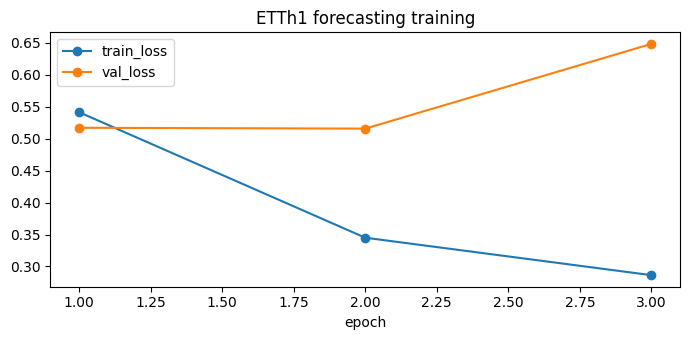

In [12]:
forecast_model = UnifiedTSModel(
    task="forecast",
    in_channels=len(value_cols),
    d_model=F_CFG.d_model,
    n_heads=F_CFG.n_heads,
    n_layers=F_CFG.n_layers,
    dropout=F_CFG.dropout,
    pred_len=F_CFG.pred_len,
)

forecast_ckpt = ARTIFACT_DIR / "forecast_best.pt"
forecast_model, f_history = fit_reconstruction_or_forecast(
    forecast_model,
    f_train_loader,
    f_val_loader,
    epochs=F_CFG.epochs,
    lr=F_CFG.lr,
    checkpoint_path=forecast_ckpt,
    task="forecast",
)
f_history.to_csv(ARTIFACT_DIR / "forecast_history.csv", index=False)
plot_history(f_history, "ETTh1 forecasting training")

{
  "model_all": {
    "MAE": 2.146024227142334,
    "MSE": 12.702247619628906,
    "RMSE": 3.5640212709282344
  },
  "persistence_all": {
    "MAE": 3.5087008476257324,
    "MSE": 45.77716827392578,
    "RMSE": 6.765882667762262
  },
  "model_OT": {
    "MAE": 2.3960609436035156,
    "MSE": 8.79592514038086,
    "RMSE": 2.9657924978630685
  },
  "persistence_OT": {
    "MAE": 2.300907850265503,
    "MSE": 9.18354320526123,
    "RMSE": 3.0304361410960685
  }
}


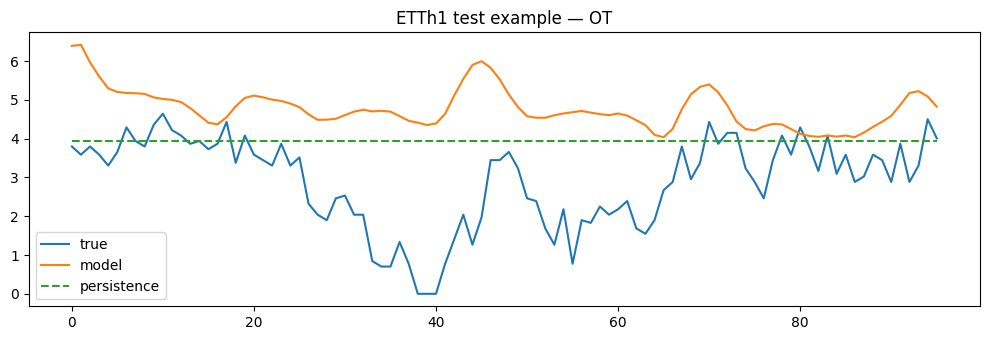

In [13]:
@torch.no_grad()
def evaluate_forecast(model, data_loader, scaler, feature_names):
    model.eval()
    preds, targets, persistence = [], [], []

    for x, y in data_loader:
        pred = model(x.to(DEVICE)).cpu().numpy()
        x_np = x.numpy()
        y_np = y.numpy()
        base = np.repeat(x_np[:, -1:, :], y_np.shape[1], axis=1)
        preds.append(pred)
        targets.append(y_np)
        persistence.append(base)

    pred_s = np.concatenate(preds)
    true_s = np.concatenate(targets)
    base_s = np.concatenate(persistence)

    C = true_s.shape[-1]
    pred = scaler.inverse_transform(pred_s.reshape(-1, C)).reshape(pred_s.shape)
    true = scaler.inverse_transform(true_s.reshape(-1, C)).reshape(true_s.shape)
    base = scaler.inverse_transform(base_s.reshape(-1, C)).reshape(base_s.shape)

    def m(y, p):
        mse = mean_squared_error(y.reshape(-1), p.reshape(-1))
        return {
            "MAE": mean_absolute_error(y.reshape(-1), p.reshape(-1)),
            "MSE": mse,
            "RMSE": math.sqrt(mse),
        }

    all_metrics = m(true, pred)
    base_metrics = m(true, base)

    ot_idx = feature_names.index("OT") if "OT" in feature_names else -1
    ot_metrics = m(true[:, :, ot_idx], pred[:, :, ot_idx])
    ot_base_metrics = m(true[:, :, ot_idx], base[:, :, ot_idx])

    return {
        "model_all": all_metrics,
        "persistence_all": base_metrics,
        "model_OT": ot_metrics,
        "persistence_OT": ot_base_metrics,
    }, pred, true, base

f_metrics, f_pred, f_true, f_base = evaluate_forecast(
    forecast_model, f_test_loader, f_scaler, value_cols
)

print(json.dumps(f_metrics, indent=2))
save_json(f_metrics, ARTIFACT_DIR / "forecast_metrics.json")

ot_idx = value_cols.index("OT") if "OT" in value_cols else -1
plt.figure(figsize=(10, 3.5))
plt.plot(f_true[0, :, ot_idx], label="true")
plt.plot(f_pred[0, :, ot_idx], label="model")
plt.plot(f_base[0, :, ot_idx], label="persistence", linestyle="--")
plt.title("ETTh1 test example — OT")
plt.legend()
plt.tight_layout()
plt.show()

### Forecasting 해석 기준

- 모델은 최소한 **persistence baseline**보다 개선되는지를 먼저 봅니다.
- 표준화 공간이 아니라 inverse-transform한 원 단위에서 MAE/MSE/RMSE를 계산합니다.
- 하나의 sample plot보다 전체 test metric이 우선입니다.
- 추가 제출 실험에서는 seed 반복, 여러 horizon(96/192/336/720)과 DLinear/MLP/GRU 같은 baseline을 더 붙일 수 있습니다.

## 8-1. Forecast latent representation diagnostics

발표자료의 “hidden state → PCA → 해석”을 다음 원칙으로 재구성합니다.

- PCA는 **train latent에만 fit**
- test latent는 transform만 수행
- PC1/PC2에 대한 feature 영향은 PCA loading을 임의로 해석하지 않고,
  **입력 feature를 train standardized mean(0)으로 가렸을 때 PC 좌표가 얼마나 변하는지**로 측정
- 결과는 인과효과가 아니라 **model sensitivity**

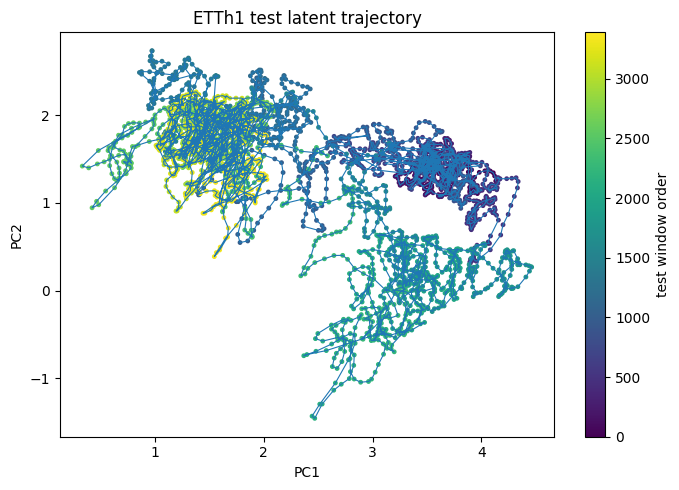

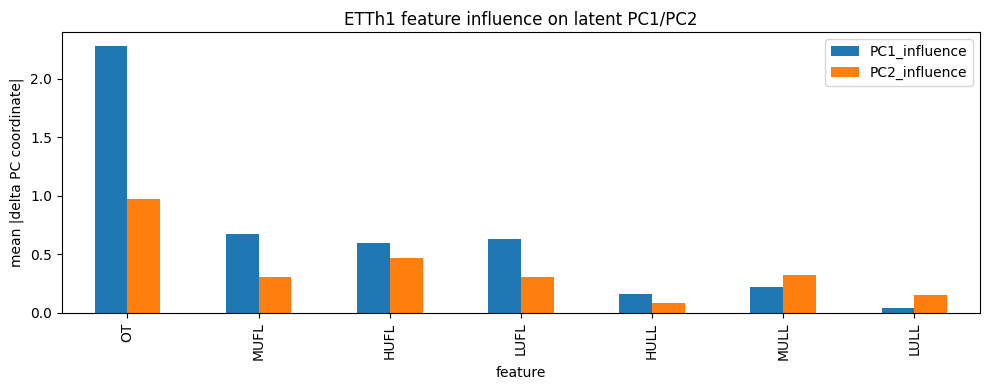

{
  "PC1_error_corr": -0.3798215748043873,
  "PC2_error_corr": 0.41233059726038773,
  "PC1_explained_variance": 0.4231020510196686,
  "PC2_explained_variance": 0.19485794007778168
}


,feature,PC1_influence,PC2_influence,latent_L2_influence
6,OT,2.284015,0.973326,4.303165
2,MUFL,0.678350,0.305144,2.772878
0,HUFL,0.595797,0.468861,2.536445
4,LUFL,0.631386,0.305810,1.925924
1,HULL,0.164891,0.086536,0.869375
3,MULL,0.218070,0.324397,0.800796
5,LULL,0.043157,0.149326,0.699008


In [14]:
@torch.no_grad()
def forecast_latent_diagnostics(model, train_ds, test_ds, batch_size, feature_names):
    train_eval_loader = loader(train_ds, batch_size, shuffle=False)
    test_eval_loader = loader(test_ds, batch_size, shuffle=False)

    z_train, _ = extract_embeddings(model, train_eval_loader)
    z_test, _ = extract_embeddings(model, test_eval_loader)

    pca = fit_pca_train_only(z_train, n_components=2)
    pc_test = pca.transform(z_test)

    errs = []
    xs = []
    max_batches = 8 if QUICK_RUN else 20

    for b_idx, (x, y) in enumerate(test_eval_loader):
        pred = model(x.to(DEVICE)).cpu().numpy()
        err = np.mean((pred - y.numpy()) ** 2, axis=(1, 2))
        errs.append(err)
        if b_idx < max_batches:
            xs.append(x)

    errs = np.concatenate(errs)

    plt.figure(figsize=(7, 5))
    plt.plot(pc_test[:, 0], pc_test[:, 1], linewidth=0.8)
    scatter = plt.scatter(
        pc_test[:, 0], pc_test[:, 1], s=6, c=np.arange(len(pc_test))
    )
    plt.colorbar(scatter, label="test window order")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("ETTh1 test latent trajectory")
    plt.tight_layout()
    plt.show()

    assoc = {
        "PC1_error_corr": float(np.corrcoef(pc_test[:, 0], errs)[0, 1]),
        "PC2_error_corr": float(np.corrcoef(pc_test[:, 1], errs)[0, 1]),
        "PC1_explained_variance": float(pca.explained_variance_ratio_[0]),
        "PC2_explained_variance": float(pca.explained_variance_ratio_[1]),
    }

    X = torch.cat(xs, dim=0).to(DEVICE)
    base_z = model.encode(X).detach().cpu().numpy()
    base_pc = pca.transform(base_z)

    rows = []
    for j, name in enumerate(feature_names):
        x_occ = X.clone()
        x_occ[:, :, j] = 0.0

        occ_z = model.encode(x_occ).detach().cpu().numpy()
        occ_pc = pca.transform(occ_z)
        delta = np.abs(occ_pc - base_pc)

        rows.append({
            "feature": name,
            "PC1_influence": float(delta[:, 0].mean()),
            "PC2_influence": float(delta[:, 1].mean()),
            "latent_L2_influence": float(
                np.linalg.norm(occ_z - base_z, axis=1).mean()
            ),
        })

    influence = pd.DataFrame(rows).sort_values(
        "latent_L2_influence", ascending=False
    )

    influence.set_index("feature")[["PC1_influence", "PC2_influence"]].plot(
        kind="bar", figsize=(10, 4)
    )
    plt.ylabel("mean |delta PC coordinate|")
    plt.title("ETTh1 feature influence on latent PC1/PC2")
    plt.tight_layout()
    plt.show()

    return assoc, influence

if RUN_LATENT_DIAGNOSTICS:
    f_latent_assoc, f_feature_influence = forecast_latent_diagnostics(
        forecast_model,
        f_train_ds,
        f_test_ds,
        F_CFG.batch_size,
        value_cols,
    )

    print(json.dumps(f_latent_assoc, indent=2))
    display(f_feature_influence)

    save_json(
        f_latent_assoc,
        ARTIFACT_DIR / "forecast_latent_association.json",
    )
    f_feature_influence.to_csv(
        ARTIFACT_DIR / "forecast_feature_latent_influence.csv",
        index=False,
    )

# 9. Task B — PSM anomaly detection

PSM/train.csv: reconstructing file:   0%|          |  0.00B / 63.6MB            

PSM/train.csv: downloading bytes:           |  0.00B            

PSM/test.csv: reconstructing file:   0%|          |  0.00B / 42.5MB            

PSM/test.csv: downloading bytes:           |  0.00B            

test_label.csv:   0%|          | 0.00/966k [00:00<?, ?B/s]


===== PSM train raw =====
shape: (132481, 26)
duplicate rows: 0
missing total: 4195
feature_21    2136
feature_6      563
feature_13     249
feature_5      249
feature_22     204
feature_4      202
feature_18     202
feature_14     202
feature_7       47
feature_10      47
dtype: int64
                         mean           std       min            max
timestamp_(min)  66240.000000  38244.114844  0.000000  132480.000000
feature_0            0.835810      0.067326  0.486490       1.000000
feature_1            0.840205      0.039472  0.525682       0.909956
feature_2            0.634216      0.102920  0.421484       1.000000
feature_3            0.575081      0.049675  0.380874       0.676682
feature_4            0.543310      0.089438  0.065106       0.929442
feature_5            0.511753      0.077771  0.110161       0.877493
feature_6            0.549268      0.064093  0.215909       1.000000

===== PSM test raw =====
shape: (87841, 26)
duplicate rows: 0
missing total: 0
           

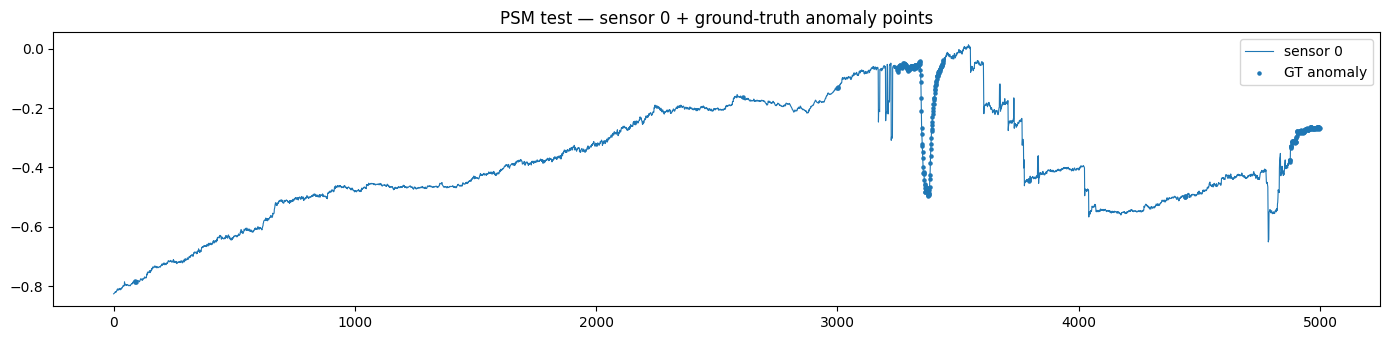

In [15]:
psm_train_raw, psm_test_raw, psm_label_raw = load_psm_raw()

compact_dataframe_report(psm_train_raw, "PSM train raw")
compact_dataframe_report(psm_test_raw, "PSM test raw")
compact_dataframe_report(psm_label_raw, "PSM test label raw")

# 첫 컬럼은 timestamp/index 성격이므로 feature/label에서 제외
psm_train_values = psm_train_raw.iloc[:, 1:].to_numpy(dtype=np.float64)
psm_test_values = psm_test_raw.iloc[:, 1:].to_numpy(dtype=np.float64)

label_values = psm_label_raw.iloc[:, 1:].to_numpy()
if label_values.ndim == 2:
    # feature-wise label이거나 1-column label인 경우 어느 센서든 anomaly면 point anomaly로 취급
    psm_labels = (label_values > 0).any(axis=1).astype(np.int64)
else:
    psm_labels = (label_values > 0).astype(np.int64)

assert len(psm_test_values) == len(psm_labels)

a_split = int(len(psm_train_values) * 0.80)
a_imputer = SimpleImputer(strategy="median")
a_scaler = StandardScaler()

train_core = a_imputer.fit_transform(psm_train_values[:a_split])
a_scaler.fit(train_core)

a_train = a_scaler.transform(train_core).astype(np.float32)
a_val = a_scaler.transform(a_imputer.transform(psm_train_values[a_split:])).astype(np.float32)
a_test = a_scaler.transform(a_imputer.transform(psm_test_values)).astype(np.float32)

a_train_ds = AnomalyWindowDataset(a_train, A_CFG.win_size, A_CFG.train_step)
a_val_ds = AnomalyWindowDataset(a_val, A_CFG.win_size, A_CFG.eval_step)
a_test_ds = AnomalyWindowDataset(a_test, A_CFG.win_size, A_CFG.eval_step)

a_train_loader = loader(a_train_ds, A_CFG.batch_size, shuffle=True)
a_val_loader = loader(a_val_ds, A_CFG.batch_size)
a_test_loader = loader(a_test_ds, A_CFG.batch_size)

print("PSM channels:", a_train.shape[1])
print("anomaly ratio in test:", psm_labels.mean())
print("windows:", len(a_train_ds), len(a_val_ds), len(a_test_ds))

plt.figure(figsize=(14, 3.5))
show_n = min(5000, len(a_test))
plt.plot(a_test[:show_n, 0], linewidth=0.8, label="sensor 0")
anom_idx = np.where(psm_labels[:show_n] == 1)[0]
if len(anom_idx):
    plt.scatter(anom_idx, a_test[anom_idx, 0], s=5, label="GT anomaly")
plt.title("PSM test — sensor 0 + ground-truth anomaly points")
plt.legend()
plt.tight_layout()
plt.show()

{'epoch': 1, 'train_loss': 0.3790225777999464, 'val_loss': 1.2648503184318542}
{'epoch': 2, 'train_loss': 0.1578223690929183, 'val_loss': 0.6734326513750213}
{'epoch': 3, 'train_loss': 0.11948824368686561, 'val_loss': 0.5426199194930849}


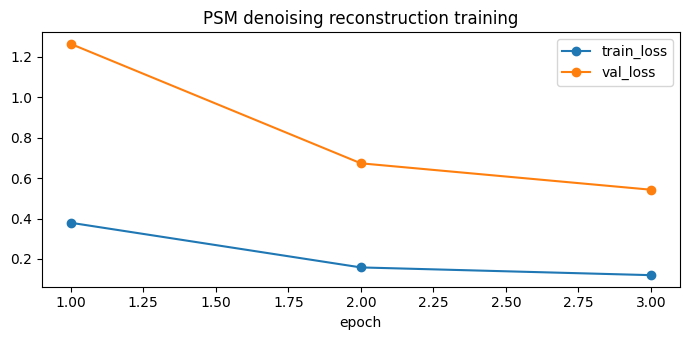

In [16]:
anomaly_model = UnifiedTSModel(
    task="anomaly",
    in_channels=a_train.shape[1],
    d_model=A_CFG.d_model,
    n_heads=A_CFG.n_heads,
    n_layers=A_CFG.n_layers,
    dropout=A_CFG.dropout,
)

anomaly_ckpt = ARTIFACT_DIR / "anomaly_best.pt"

# v2: masked denoising reconstruction
anomaly_model, a_history = fit_masked_autoencoder(
    anomaly_model,
    a_train_loader,
    a_val_loader,
    epochs=A_CFG.epochs,
    lr=A_CFG.lr,
    checkpoint_path=anomaly_ckpt,
    mask_ratio=0.15,
)

a_history.to_csv(ARTIFACT_DIR / "anomaly_history.csv", index=False)
plot_history(a_history, "PSM denoising reconstruction training")

## 9-1. Point-wise anomaly score aggregation

겹치는 reconstruction window들의 timestep MSE를 원래 시간축으로 다시 평균합니다.  
따라서 각 timestamp는 여러 window에서 얻은 reconstruction error의 평균 score를 갖습니다.

In [17]:
@torch.no_grad()
def reconstruction_window_outputs(model, data_loader):
    model.eval()

    window_mean_scores = []
    starts_all = []
    embeddings = []

    for x, starts in data_loader:
        x_dev = x.to(DEVICE)
        rec = model(x_dev)
        err = ((rec - x_dev) ** 2).mean(dim=-1)

        window_mean_scores.append(err.mean(dim=1).cpu().numpy())
        starts_all.append(starts.numpy())
        embeddings.append(model.encode(x_dev).cpu().numpy())

    return (
        np.concatenate(window_mean_scores),
        np.concatenate(starts_all),
        np.concatenate(embeddings),
    )

@torch.no_grad()
def pointwise_reconstruction_scores(model, data_loader, series_length, win_size):
    model.eval()
    score_sum = np.zeros(series_length, dtype=np.float64)
    score_count = np.zeros(series_length, dtype=np.float64)

    for x, starts in data_loader:
        x_dev = x.to(DEVICE)
        rec = model(x_dev)
        err = ((rec - x_dev) ** 2).mean(dim=-1).cpu().numpy()

        for e, s in zip(err, starts.numpy()):
            s = int(s)
            score_sum[s:s+win_size] += e
            score_count[s:s+win_size] += 1

    covered = score_count > 0
    scores = np.zeros(series_length, dtype=np.float64)
    scores[covered] = score_sum[covered] / score_count[covered]

    if (~covered).any():
        scores[~covered] = np.median(scores[covered])

    return scores

def build_hybrid_latent_shock_scores(
    model,
    train_loader,
    val_loader,
    test_loader,
    train_length,
    val_length,
    test_length,
    win_size,
):
    train_rec = pointwise_reconstruction_scores(
        model, train_loader, train_length, win_size
    )
    val_rec = pointwise_reconstruction_scores(
        model, val_loader, val_length, win_size
    )
    test_rec = pointwise_reconstruction_scores(
        model, test_loader, test_length, win_size
    )

    _, tr_starts, z_train = reconstruction_window_outputs(
        model, train_loader
    )
    _, va_starts, z_val = reconstruction_window_outputs(
        model, val_loader
    )
    _, te_starts, z_test = reconstruction_window_outputs(
        model, test_loader
    )

    oas = OAS(
        store_precision=True,
        assume_centered=False,
    ).fit(z_train)

    mu = oas.location_
    precision = oas.precision_

    tr_maha = mahalanobis_scores(z_train, mu, precision)
    va_maha = mahalanobis_scores(z_val, mu, precision)
    te_maha = mahalanobis_scores(z_test, mu, precision)

    tr_vel = latent_velocity(z_train)
    va_vel = latent_velocity(z_val)
    te_vel = latent_velocity(z_test)

    train_maha = aggregate_window_scalar_scores(
        tr_starts, tr_maha, train_length, win_size
    )
    val_maha = aggregate_window_scalar_scores(
        va_starts, va_maha, val_length, win_size
    )
    test_maha = aggregate_window_scalar_scores(
        te_starts, te_maha, test_length, win_size
    )

    train_vel = aggregate_window_scalar_scores(
        tr_starts, tr_vel, train_length, win_size
    )
    val_vel = aggregate_window_scalar_scores(
        va_starts, va_vel, val_length, win_size
    )
    test_vel = aggregate_window_scalar_scores(
        te_starts, te_vel, test_length, win_size
    )

    calibrated = {}
    hybrid_val = np.zeros(val_length, dtype=np.float64)
    hybrid_test = np.zeros(test_length, dtype=np.float64)

    for name, va, te in [
        ("reconstruction", val_rec, test_rec),
        ("mahalanobis", val_maha, test_maha),
        ("latent_velocity", val_vel, test_vel),
    ]:
        center, scale = robust_location_scale(va)
        va_z = robust_standardize(va, center, scale)
        te_z = robust_standardize(te, center, scale)

        calibrated[name] = {
            "center": float(center),
            "scale": float(scale),
        }

        hybrid_val += va_z
        hybrid_test += te_z

    hybrid_val /= 3.0
    hybrid_test /= 3.0

    diagnostics = {
        "train_embeddings": z_train,
        "val_embeddings": z_val,
        "test_embeddings": z_test,
        "val_components": {
            "reconstruction": val_rec,
            "mahalanobis": val_maha,
            "latent_velocity": val_vel,
        },
        "test_components": {
            "reconstruction": test_rec,
            "mahalanobis": test_maha,
            "latent_velocity": test_vel,
        },
        "calibration": calibrated,
    }

    return hybrid_val, hybrid_test, diagnostics

hybrid_val_scores, hybrid_test_scores, latent_diag = build_hybrid_latent_shock_scores(
    anomaly_model,
    loader(a_train_ds, A_CFG.batch_size, shuffle=False),
    a_val_loader,
    a_test_loader,
    len(a_train),
    len(a_val),
    len(a_test),
    A_CFG.win_size,
)

threshold = float(
    np.quantile(hybrid_val_scores, A_CFG.threshold_quantile)
)
test_scores = hybrid_test_scores
test_pred = (test_scores > threshold).astype(np.int64)

print("hybrid threshold:", threshold)
print("predicted anomaly ratio:", test_pred.mean())
print("shock components:", list(latent_diag["test_components"]))

hybrid threshold: 2.6976995550144287
predicted anomaly ratio: 0.008025864915016905
shock components: ['reconstruction', 'mahalanobis', 'latent_velocity']


## 9-2. Latent shock decomposition

발표자료의 `latent inner product = shock` 아이디어는 scale과 representation 좌표계에 민감합니다.
v2에서는 이를 다음과 같이 정식화합니다.

\[
S_t =
\frac{1}{3}\left(
Z_{\mathrm{robust}}(E_t^{rec})
+
Z_{\mathrm{robust}}(D_t^{Mahalanobis})
+
Z_{\mathrm{robust}}(V_t^{latent})
\right)
\]

- \(E_t^{rec}\): reconstruction error
- \(D_t^{Mahalanobis}\): 정상 train latent 분포에서 얼마나 멀리 떨어졌는지
- \(V_t^{latent}\): 시간에 따라 latent가 얼마나 빠르게 이동하는지

따라서 “관측 재구성 실패”, “정상 manifold 이탈”, “상태의 급격한 변화”를 분리해서 확인할 수 있습니다.

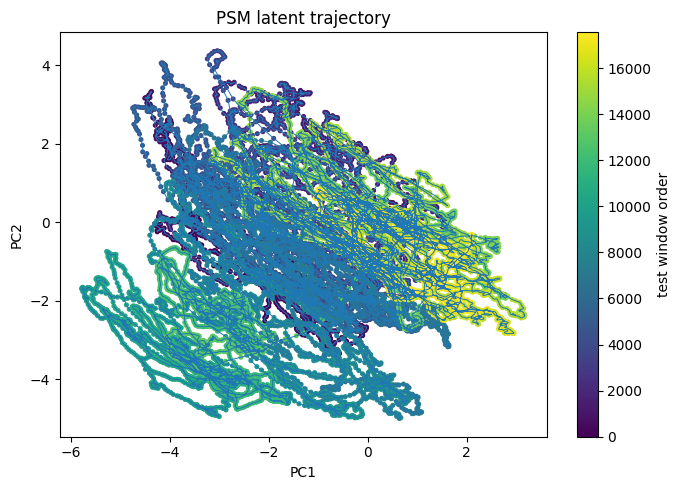

Mean score by ground-truth label (post-hoc analysis)


,reconstruction,mahalanobis,latent_velocity,hybrid
label,,,,
0,0.340760,11.988530,0.158027,-0.076068
1,0.965667,15.605444,0.159451,0.786822


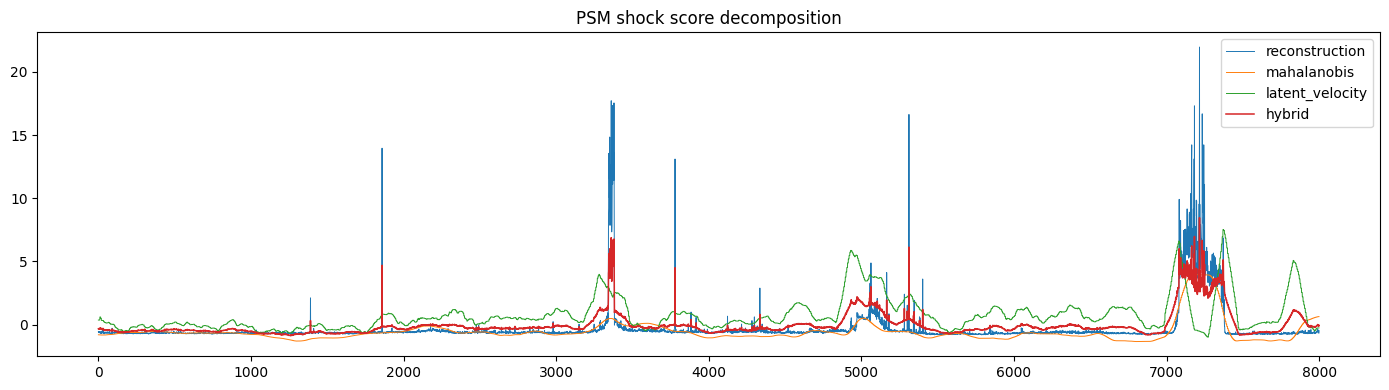

In [18]:
if RUN_LATENT_DIAGNOSTICS:
    z_train = latent_diag["train_embeddings"]
    z_test = latent_diag["test_embeddings"]

    pca_a = fit_pca_train_only(z_train, n_components=2)
    pc_a = pca_a.transform(z_test)

    plt.figure(figsize=(7, 5))
    plt.plot(pc_a[:, 0], pc_a[:, 1], linewidth=0.7)
    scatter = plt.scatter(
        pc_a[:, 0],
        pc_a[:, 1],
        s=7,
        c=np.arange(len(pc_a)),
    )
    plt.colorbar(scatter, label="test window order")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PSM latent trajectory")
    plt.tight_layout()
    plt.show()

    component_df = pd.DataFrame({
        "reconstruction": latent_diag["test_components"]["reconstruction"],
        "mahalanobis": latent_diag["test_components"]["mahalanobis"],
        "latent_velocity": latent_diag["test_components"]["latent_velocity"],
        "hybrid": test_scores,
        "label": psm_labels,
    })

    print("Mean score by ground-truth label (post-hoc analysis)")
    display(component_df.groupby("label").mean())

    component_df.to_csv(
        ARTIFACT_DIR / "anomaly_shock_components.csv",
        index=False,
    )

    plt.figure(figsize=(14, 4))
    show_n = min(8000, len(component_df))

    for col in ["reconstruction", "mahalanobis", "latent_velocity"]:
        x = component_df[col].to_numpy()[:show_n]
        c0, s0 = robust_location_scale(
            latent_diag["val_components"][col]
        )
        plt.plot(
            robust_standardize(x, c0, s0),
            linewidth=0.7,
            label=col,
        )

    plt.plot(
        test_scores[:show_n],
        linewidth=1.1,
        label="hybrid",
    )
    plt.title("PSM shock score decomposition")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 9-3. PA%K 직접 구현

PA%K의 핵심:
- ground-truth anomaly segment 내부에서 예측된 anomaly 비율이 `K%`를 **초과**할 때만 그 segment 전체를 point-adjust.
- `K=0` → 기존 PA처럼 segment 안에서 하나라도 잡으면 전체 segment를 맞춘 것으로 조정.
- `K=100` → 어떤 segment도 추가 조정되지 않으므로 일반 point-wise F1과 같음.

이 구현은 test label을 **평가 후처리**에만 사용하며 threshold 결정에는 사용하지 않습니다.

In [19]:
def contiguous_segments(y_true: np.ndarray):
    y = np.asarray(y_true).astype(int)
    segments = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        if start is not None and (v == 0 or i == len(y)-1):
            end = i if v == 0 else i + 1
            segments.append((start, end))
            start = None
    return segments

def point_adjust_at_k(y_true: np.ndarray, y_pred: np.ndarray, k_percent: float):
    y_true = np.asarray(y_true).astype(int)
    adjusted = np.asarray(y_pred).astype(int).copy()
    ratio_threshold = k_percent / 100.0

    for s, e in contiguous_segments(y_true):
        detected_ratio = adjusted[s:e].mean()
        if detected_ratio > ratio_threshold:
            adjusted[s:e] = 1
    return adjusted

def pa_at_k_metrics(y_true, y_pred, k_percent):
    adj = point_adjust_at_k(y_true, y_pred, k_percent)
    return {
        "K": float(k_percent),
        "precision": precision_score(y_true, adj, zero_division=0),
        "recall": recall_score(y_true, adj, zero_division=0),
        "f1": f1_score(y_true, adj, zero_division=0),
    }

def pa_k_unit_test():
    y = np.array([0, 1, 1, 1, 0])
    p = np.array([0, 0, 1, 0, 0])

    k0 = point_adjust_at_k(y, p, 0)
    k100 = point_adjust_at_k(y, p, 100)

    assert np.array_equal(k0, np.array([0,1,1,1,0]))
    assert np.array_equal(k100, p)
    assert f1_score(y, k0) > f1_score(y, k100)
    print("✓ PA%K unit test passed")

pa_k_unit_test()

✓ PA%K unit test passed


=== UnifiedTS hybrid latent-shock model ===
{
  "threshold": 2.6976995550144287,
  "point_precision": 0.9092198581560283,
  "point_recall": 0.0262909642754604,
  "point_f1": 0.051104201546679426,
  "AUROC": 0.8056268008367482,
  "AUPRC": 0.6074995556747194,
  "PA0_F1": 0.9029015102214842,
  "PA100_F1": 0.051104201546679426,
  "PAK_AUC": 0.09969992345114596
}

=== Standardized-magnitude baseline ===
{
  "threshold": 16.97675323486328,
  "point_precision": 1.0,
  "point_recall": 0.014724580616053484,
  "point_f1": 0.02902182700080841,
  "AUROC": 0.687667365365763,
  "AUPRC": 0.5363672843681598,
  "PA0_F1": 0.8340865074241446,
  "PA100_F1": 0.02902182700080841,
  "PAK_AUC": 0.07376023723527664
}


,K,precision,recall,f1
0,0.0,0.996829,0.825151,0.902902
1,10.0,0.935807,0.038268,0.073528
2,20.0,0.920200,0.030269,0.058611
3,30.0,0.919900,0.030146,0.058380
4,40.0,0.917738,0.029285,0.056759
5,50.0,0.917738,0.029285,0.056759
6,60.0,0.917738,0.029285,0.056759
7,70.0,0.917738,0.029285,0.056759
8,80.0,0.909605,0.026414,0.051337
9,90.0,0.909220,0.026291,0.051104


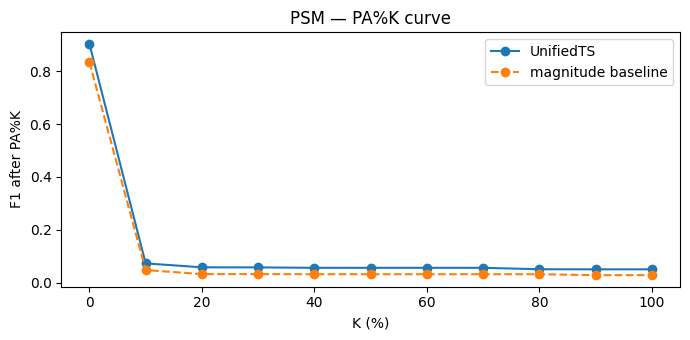

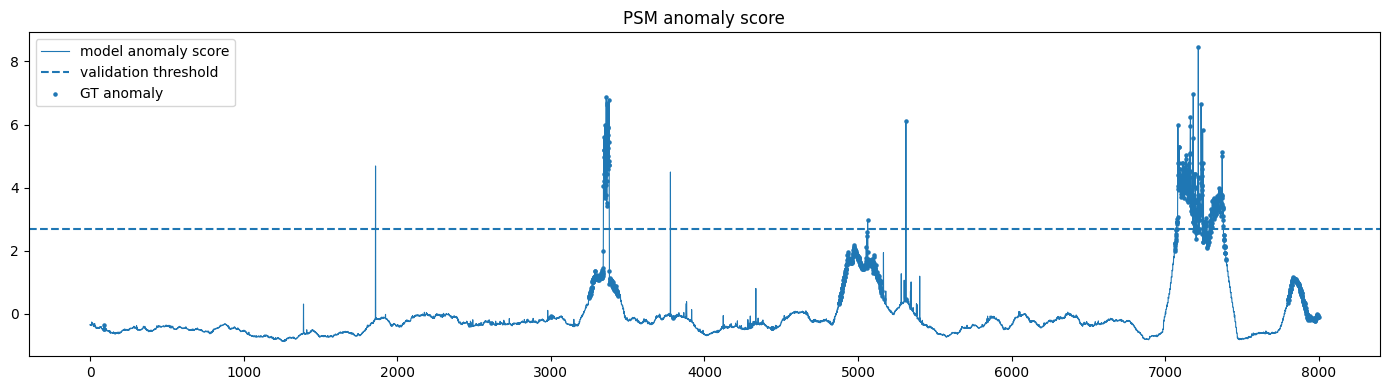

In [20]:
def evaluate_anomaly(y_true, y_pred, scores, threshold_value):
    out = {
        "threshold": float(threshold_value),
        "point_precision": precision_score(y_true, y_pred, zero_division=0),
        "point_recall": recall_score(y_true, y_pred, zero_division=0),
        "point_f1": f1_score(y_true, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_true, scores),
        "AUPRC": average_precision_score(y_true, scores),
    }

    curve = [pa_at_k_metrics(y_true, y_pred, k) for k in range(0, 101, 10)]
    ks = np.array([r["K"] for r in curve], dtype=float)
    fs = np.array([r["f1"] for r in curve], dtype=float)
    out["PA0_F1"] = curve[0]["f1"]
    out["PA100_F1"] = curve[-1]["f1"]
    out["PAK_AUC"] = float(np.trapezoid(fs, ks) / 100.0)
    return out, pd.DataFrame(curve)

# UnifiedTS hybrid latent-shock detector
a_metrics, pak_curve = evaluate_anomaly(
    psm_labels, test_pred, test_scores, threshold
)

# Simple baseline:
# train-only standardized feature magnitude. No temporal model and no test-label threshold tuning.
baseline_val_scores = np.mean(a_val ** 2, axis=1)
baseline_test_scores = np.mean(a_test ** 2, axis=1)
baseline_threshold = float(np.quantile(baseline_val_scores, A_CFG.threshold_quantile))
baseline_pred = (baseline_test_scores > baseline_threshold).astype(np.int64)

a_baseline_metrics, baseline_pak_curve = evaluate_anomaly(
    psm_labels, baseline_pred, baseline_test_scores, baseline_threshold
)

print("=== UnifiedTS hybrid latent-shock model ===")
print(json.dumps(a_metrics, indent=2))
print("\n=== Standardized-magnitude baseline ===")
print(json.dumps(a_baseline_metrics, indent=2))

display(pak_curve)

save_json(a_metrics, ARTIFACT_DIR / "anomaly_metrics.json")
save_json(a_baseline_metrics, ARTIFACT_DIR / "anomaly_baseline_metrics.json")
pak_curve.to_csv(ARTIFACT_DIR / "pa_k_curve.csv", index=False)

plt.figure(figsize=(7, 3.5))
plt.plot(pak_curve["K"], pak_curve["f1"], marker="o", label="UnifiedTS")
plt.plot(
    baseline_pak_curve["K"],
    baseline_pak_curve["f1"],
    marker="o",
    linestyle="--",
    label="magnitude baseline",
)
plt.xlabel("K (%)")
plt.ylabel("F1 after PA%K")
plt.title("PSM — PA%K curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
show_n = min(8000, len(test_scores))
plt.plot(test_scores[:show_n], label="model anomaly score", linewidth=0.8)
plt.axhline(threshold, linestyle="--", label="validation threshold")
gt = np.where(psm_labels[:show_n] == 1)[0]
if len(gt):
    plt.scatter(gt, test_scores[gt], s=5, label="GT anomaly")
plt.title("PSM anomaly score")
plt.legend()
plt.tight_layout()
plt.show()

### Anomaly detection 해석 기준

- `PA0_F1`만 높고 `PA100_F1`/point-F1이 낮으면 한 anomaly segment의 일부만 우연히 잡고 PA로 성능이 크게 부풀려질 수 있습니다.
- 따라서 **point-F1, AUPRC, PA%K curve를 같이** 확인합니다.
- threshold는 test label을 이용해 최고 F1로 맞추지 않았기 때문에 실제 deployment 상황에 더 가깝습니다.

## 9-4. Optional multi-seed stability check

발표자료에서 한계로 지적했던 “실험 반복 시 결과의 일관성 부족”을 직접 측정합니다.

`RUN_STABILITY_CHECK=True`이면 anomaly model을 다른 seed로 한 번 더 학습하고,

- shock score Pearson correlation
- 상위 1% shock timestamp Jaccard overlap

을 계산합니다.

기본 실행시간을 지나치게 늘리지 않기 위해 기본값은 `False`입니다.

In [21]:
if RUN_STABILITY_CHECK:
    seed_everything(SEED + 101)

    anomaly_model_seed2 = UnifiedTSModel(
        task="anomaly",
        in_channels=a_train.shape[1],
        d_model=A_CFG.d_model,
        n_heads=A_CFG.n_heads,
        n_layers=A_CFG.n_layers,
        dropout=A_CFG.dropout,
    )

    ckpt2 = ARTIFACT_DIR / "anomaly_seed2_best.pt"

    anomaly_model_seed2, _ = fit_masked_autoencoder(
        anomaly_model_seed2,
        loader(a_train_ds, A_CFG.batch_size, shuffle=True),
        a_val_loader,
        epochs=A_CFG.epochs,
        lr=A_CFG.lr,
        checkpoint_path=ckpt2,
        mask_ratio=0.15,
    )

    _, seed2_test_scores, _ = build_hybrid_latent_shock_scores(
        anomaly_model_seed2,
        loader(a_train_ds, A_CFG.batch_size, shuffle=False),
        a_val_loader,
        a_test_loader,
        len(a_train),
        len(a_val),
        len(a_test),
        A_CFG.win_size,
    )

    stability = score_stability_report(
        test_scores,
        seed2_test_scores,
        top_frac=0.01,
    )

    print(json.dumps(stability, indent=2))
    save_json(
        stability,
        ARTIFACT_DIR / "anomaly_seed_stability.json",
    )

    seed_everything(SEED)

# 10. Task C — UEA Libras classification

official train shape: (180, 2, 45)
official test shape : (180, 2, 45)
train labels: {'1': 12, '10': 12, '11': 12, '12': 12, '13': 12, '14': 12, '15': 12, '2': 12, '3': 12, '4': 12, '5': 12, '6': 12, '7': 12, '8': 12, '9': 12}
n_classes: 15
train/val/test: 144 36 180
input shape: torch.Size([32, 45, 2])


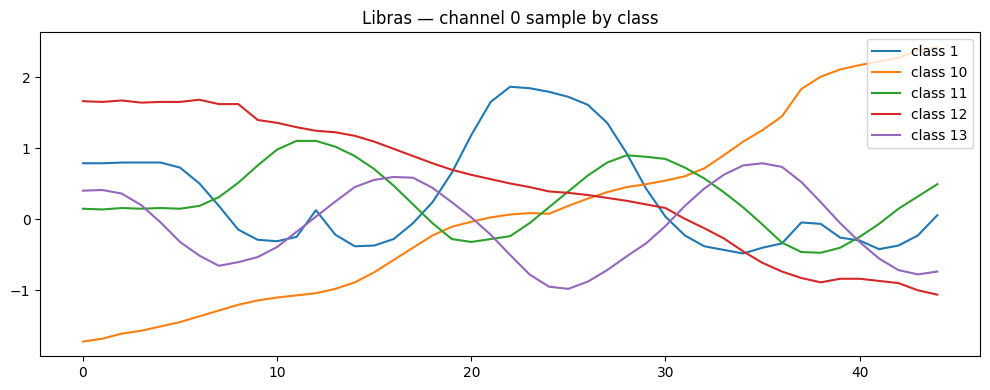

In [22]:
X_official_train, y_official_train, X_test_raw, y_test_raw = load_libras_raw()

print("official train shape:", np.asarray(X_official_train).shape)
print("official test shape :", np.asarray(X_test_raw).shape)
print("train labels:", pd.Series(y_official_train).value_counts().sort_index().to_dict())

label_encoder = LabelEncoder()
label_encoder.fit(y_official_train)

y_all = label_encoder.transform(y_official_train)
y_test = label_encoder.transform(y_test_raw)

indices = np.arange(len(y_all))
tr_idx, va_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all,
)

X_all = np.asarray(X_official_train, dtype=np.float64)
X_test_arr = np.asarray(X_test_raw, dtype=np.float64)

# channel-wise scaling: [N,C,L] -> [N*L,C]
def fit_channel_scaler(X_train_subset):
    C = X_train_subset.shape[1]
    flat = X_train_subset.transpose(0, 2, 1).reshape(-1, C)
    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()
    flat_imp = imp.fit_transform(flat)
    sc.fit(flat_imp)
    return imp, sc

def transform_channels(X, imp, sc):
    N, C, L = X.shape
    flat = X.transpose(0, 2, 1).reshape(-1, C)
    flat = imp.transform(flat)
    flat = sc.transform(flat)
    return flat.reshape(N, L, C).transpose(0, 2, 1).astype(np.float32)

c_imputer, c_scaler = fit_channel_scaler(X_all[tr_idx])

X_train = transform_channels(X_all[tr_idx], c_imputer, c_scaler)
X_val = transform_channels(X_all[va_idx], c_imputer, c_scaler)
X_test = transform_channels(X_test_arr, c_imputer, c_scaler)

y_train = y_all[tr_idx]
y_val = y_all[va_idx]

c_train_ds = ClassificationDataset(X_train, y_train)
c_val_ds = ClassificationDataset(X_val, y_val)
c_test_ds = ClassificationDataset(X_test, y_test)

c_train_loader = loader(c_train_ds, C_CFG.batch_size, shuffle=True)
c_val_loader = loader(c_val_ds, C_CFG.batch_size)
c_test_loader = loader(c_test_ds, C_CFG.batch_size)

print("n_classes:", len(label_encoder.classes_))
print("train/val/test:", len(c_train_ds), len(c_val_ds), len(c_test_ds))
print("input shape:", next(iter(c_train_loader))[0].shape)

# 클래스별 첫 sample 몇 개 시각화
plt.figure(figsize=(10, 4))
for cls in np.unique(y_train)[:5]:
    idx = np.where(y_train == cls)[0][0]
    sample = X_train[idx]  # [C,L]
    plt.plot(sample[0], label=f"class {label_encoder.inverse_transform([cls])[0]}")
plt.title("Libras — channel 0 sample by class")
plt.legend()
plt.tight_layout()
plt.show()

{'epoch': 1, 'train_loss': 2.712450551986694, 'train_acc': 0.10416666666666667, 'val_loss': 2.7223639488220215, 'val_acc': 0.08333333333333333}
{'epoch': 2, 'train_loss': 2.6396536350250246, 'train_acc': 0.14583333333333334, 'val_loss': 2.6912341117858887, 'val_acc': 0.1111111111111111}
{'epoch': 3, 'train_loss': 2.552098035812378, 'train_acc': 0.18055555555555555, 'val_loss': 2.6670374870300293, 'val_acc': 0.1111111111111111}
{'epoch': 4, 'train_loss': 2.4940289497375487, 'train_acc': 0.20833333333333334, 'val_loss': 2.6217825412750244, 'val_acc': 0.1388888888888889}
{'epoch': 5, 'train_loss': 2.3975921154022215, 'train_acc': 0.2361111111111111, 'val_loss': 2.5376721620559692, 'val_acc': 0.19444444444444445}
{'epoch': 6, 'train_loss': 2.3161316394805906, 'train_acc': 0.2708333333333333, 'val_loss': 2.4732840061187744, 'val_acc': 0.19444444444444445}
{'epoch': 7, 'train_loss': 2.207568883895874, 'train_acc': 0.3333333333333333, 'val_loss': 2.421805739402771, 'val_acc': 0.25}
{'epoch': 

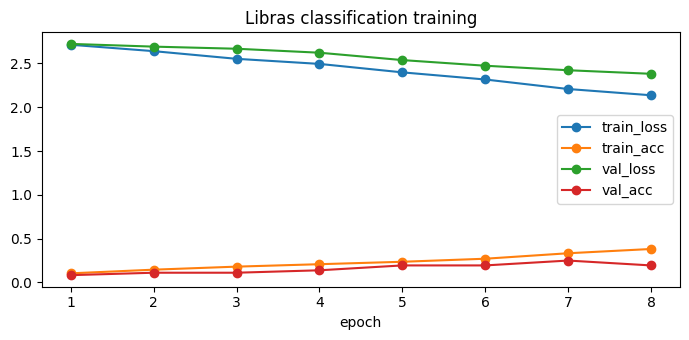

In [23]:
classification_model = UnifiedTSModel(
    task="classification",
    in_channels=X_train.shape[1],
    d_model=C_CFG.d_model,
    n_heads=C_CFG.n_heads,
    n_layers=C_CFG.n_layers,
    dropout=C_CFG.dropout,
    n_classes=len(label_encoder.classes_),
)

classification_ckpt = ARTIFACT_DIR / "classification_best.pt"
classification_model, c_history = fit_classifier(
    classification_model,
    c_train_loader,
    c_val_loader,
    epochs=C_CFG.epochs,
    lr=C_CFG.lr,
    checkpoint_path=classification_ckpt,
)
c_history.to_csv(ARTIFACT_DIR / "classification_history.csv", index=False)
plot_history(c_history, "Libras classification training")

{
  "accuracy": 0.26666666666666666,
  "macro_f1": 0.2077896668391127,
  "weighted_f1": 0.2077896668391127,
  "majority_accuracy": 0.06666666666666667
}
              precision    recall  f1-score   support

           1       0.33      0.50      0.40        12
          10       0.18      0.17      0.17        12
          11       0.33      0.42      0.37        12
          12       0.00      0.00      0.00        12
          13       0.50      0.17      0.25        12
          14       0.19      0.83      0.31        12
          15       0.00      0.00      0.00        12
           2       0.00      0.00      0.00        12
           3       0.00      0.00      0.00        12
           4       0.26      0.83      0.40        12
           5       0.75      0.25      0.38        12
           6       0.20      0.08      0.12        12
           7       0.00      0.00      0.00        12
           8       0.67      0.33      0.44        12
           9       0.21      0.42   

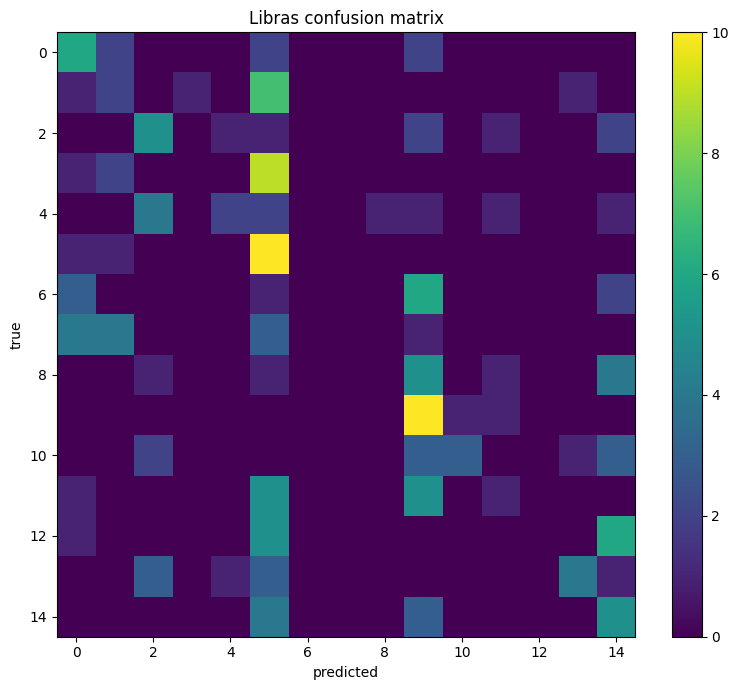

In [24]:
@torch.no_grad()
def evaluate_classifier(model, data_loader):
    model.eval()
    preds, targets = [], []
    for x, y in data_loader:
        logits = model(x.to(DEVICE))
        preds.append(logits.argmax(-1).cpu().numpy())
        targets.append(y.numpy())
    return np.concatenate(preds), np.concatenate(targets)

c_pred, c_true = evaluate_classifier(classification_model, c_test_loader)

c_metrics = {
    "accuracy": accuracy_score(c_true, c_pred),
    "macro_f1": f1_score(c_true, c_pred, average="macro"),
    "weighted_f1": f1_score(c_true, c_pred, average="weighted"),
}

# 단순 majority-class baseline
majority = np.bincount(y_train).argmax()
majority_pred = np.full_like(c_true, majority)
c_metrics["majority_accuracy"] = accuracy_score(c_true, majority_pred)

print(json.dumps(c_metrics, indent=2))
print(classification_report(
    c_true,
    c_pred,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=[str(x) for x in label_encoder.classes_],
    zero_division=0,
))
save_json(c_metrics, ARTIFACT_DIR / "classification_metrics.json")

cm = confusion_matrix(c_true, c_pred, labels=np.arange(len(label_encoder.classes_)))
plt.figure(figsize=(8, 7))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.title("Libras confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.tight_layout()
plt.show()

## 10-1. Classification latent-space diagnostics

분류 정확도만으로는 encoder가 어떤 구조를 학습했는지 알기 어렵습니다.

- PCA는 train embedding에만 fit
- test embedding을 class별로 사후 시각화
- latent class centroid 기반 nearest-centroid accuracy
- channel occlusion으로 모델의 channel sensitivity 확인

test label은 오직 **사후 평가/시각화**에만 사용합니다.

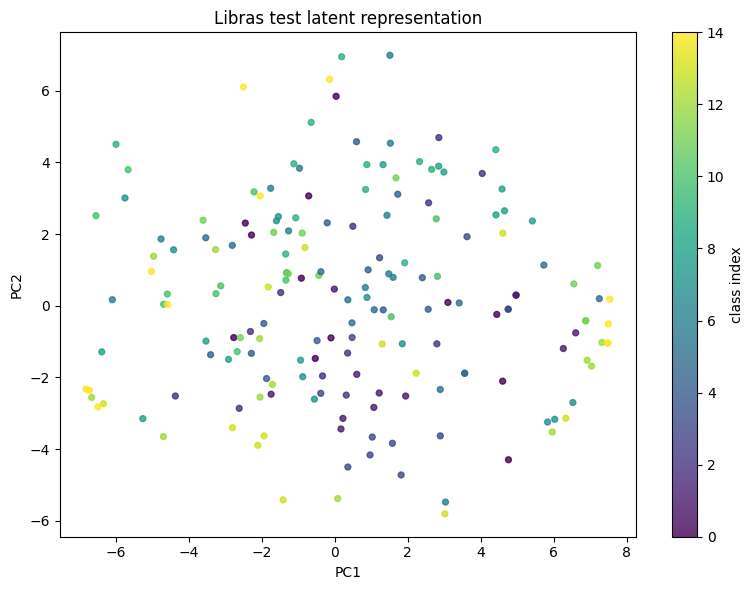

{
  "latent_centroid_accuracy": 0.3055555555555556,
  "PC1_explained_variance": 0.4545964002609253,
  "PC2_explained_variance": 0.35389915108680725,
  "latent_silhouette": -0.11928194761276245
}


,channel,mean_true_class_probability_drop
1,1,0.044983
0,0,0.032157


In [25]:
@torch.no_grad()
def classification_latent_diagnostics(
    model,
    train_ds,
    test_ds,
    batch_size,
    n_classes,
):
    tr_loader = loader(train_ds, batch_size, shuffle=False)
    te_loader = loader(test_ds, batch_size, shuffle=False)

    z_tr, y_tr = extract_embeddings(model, tr_loader)
    z_te, y_te = extract_embeddings(model, te_loader)

    pca = fit_pca_train_only(z_tr, 2)
    pc_te = pca.transform(z_te)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        pc_te[:, 0],
        pc_te[:, 1],
        c=y_te,
        s=18,
        alpha=0.8,
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Libras test latent representation")
    plt.colorbar(scatter, label="class index")
    plt.tight_layout()
    plt.show()

    centroids = np.stack([
        z_tr[y_tr == k].mean(axis=0)
        for k in range(n_classes)
    ])

    d2 = (
        (z_te[:, None, :] - centroids[None, :, :]) ** 2
    ).sum(axis=-1)
    centroid_pred = d2.argmin(axis=1)

    report = {
        "latent_centroid_accuracy": float(
            accuracy_score(y_te, centroid_pred)
        ),
        "PC1_explained_variance": float(
            pca.explained_variance_ratio_[0]
        ),
        "PC2_explained_variance": float(
            pca.explained_variance_ratio_[1]
        ),
    }

    if (
        len(np.unique(y_te)) > 1
        and len(z_te) > len(np.unique(y_te))
    ):
        report["latent_silhouette"] = float(
            silhouette_score(z_te, y_te)
        )

    xs, ys = [], []

    for b_idx, (x, y) in enumerate(te_loader):
        xs.append(x)
        ys.append(y)

        if b_idx >= (4 if QUICK_RUN else 20):
            break

    X = torch.cat(xs).to(DEVICE)
    Y = torch.cat(ys).to(DEVICE)

    base_prob = torch.softmax(model(X), dim=-1)
    row_idx = torch.arange(len(Y), device=DEVICE)
    base_true_prob = base_prob[row_idx, Y]

    rows = []

    for j in range(X.shape[-1]):
        x_occ = X.clone()
        x_occ[:, :, j] = 0.0

        p = torch.softmax(model(x_occ), dim=-1)
        true_prob = p[row_idx, Y]

        rows.append({
            "channel": j,
            "mean_true_class_probability_drop": float(
                (base_true_prob - true_prob).mean().cpu()
            ),
        })

    channel_importance = pd.DataFrame(rows).sort_values(
        "mean_true_class_probability_drop",
        ascending=False,
    )

    return report, channel_importance

if RUN_LATENT_DIAGNOSTICS:
    c_latent_report, c_channel_importance = classification_latent_diagnostics(
        classification_model,
        c_train_ds,
        c_test_ds,
        C_CFG.batch_size,
        len(label_encoder.classes_),
    )

    print(json.dumps(c_latent_report, indent=2))
    display(c_channel_importance)

    save_json(
        c_latent_report,
        ARTIFACT_DIR / "classification_latent_report.json",
    )
    c_channel_importance.to_csv(
        ARTIFACT_DIR / "classification_channel_importance.csv",
        index=False,
    )

# 11. Optional Research Extension — Multi-Asset Market Shock Representation

이 section은 원 코딩 테스트의 benchmark 성능에 포함되지 않는 **별도 연구 확장**입니다.

### Assets
- KOSPI
- USD/KRW
- WTI
- S&P 500
- US 10Y
- Gold
- VIX

### 실험 설계
- 2015년 이후 daily data
- log-return 기반 multivariate panel
- **train: 2015–2018**
- **validation-normal: 2019**
- **test: 2020 이후**
- masked temporal autoencoder
- latent PCA
- reconstruction + Mahalanobis + latent velocity ensemble

이 split은 2020년 이후의 큰 시장 변화가 train preprocessing 및 threshold에 들어가는 것을 막기 위한
의도적인 out-of-sample case study입니다.

> 높은 shock score는 “모델 representation이 정상 학습 구간과 달라졌다”는 의미입니다.
> 특정 주체가 먼저 반응했다거나 특정 사건이 원인이라는 인과적 결론을 의미하지 않습니다.

In [26]:
def run_market_shock_case_study():
    import yfinance as yf

    symbol_map = {
        "KOSPI": "^KS11",
        "USD_KRW": "KRW=X",
        "WTI": "CL=F",
        "SP500": "^GSPC",
        "US10Y": "^TNX",
        "GOLD": "GC=F",
        "VIX": "^VIX",
    }

    raw = yf.download(
        list(symbol_map.values()),
        start="2015-01-01",
        end=None,
        auto_adjust=True,
        progress=False,
        group_by="column",
    )

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].copy()

    inv_map = {v: k for k, v in symbol_map.items()}
    prices = prices.rename(columns=inv_map)
    prices = prices[list(symbol_map)].dropna(how="any")

    returns = np.log(prices).diff().dropna()

    train_mask = returns.index < "2019-01-01"
    val_mask = (
        (returns.index >= "2019-01-01")
        & (returns.index < "2020-01-01")
    )
    test_mask = returns.index >= "2020-01-01"

    if min(
        train_mask.sum(),
        val_mask.sum(),
        test_mask.sum(),
    ) < 100:
        raise RuntimeError(
            "market split has insufficient observations"
        )

    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()

    tr_raw = imp.fit_transform(returns.loc[train_mask])
    sc.fit(tr_raw)

    tr = sc.transform(tr_raw).astype(np.float32)
    va = sc.transform(
        imp.transform(returns.loc[val_mask])
    ).astype(np.float32)
    te = sc.transform(
        imp.transform(returns.loc[test_mask])
    ).astype(np.float32)

    win = 60
    step = 5

    tr_ds = AnomalyWindowDataset(tr, win, step)
    va_ds = AnomalyWindowDataset(va, win, step)
    te_ds = AnomalyWindowDataset(te, win, step)

    tr_loader = loader(tr_ds, 64, shuffle=True)
    tr_eval_loader = loader(tr_ds, 64, shuffle=False)
    va_loader = loader(va_ds, 64)
    te_loader = loader(te_ds, 64)

    model = UnifiedTSModel(
        task="anomaly",
        in_channels=tr.shape[1],
        d_model=64,
        n_heads=4,
        n_layers=2,
        dropout=0.1,
    )

    ckpt = ARTIFACT_DIR / "market_shock_encoder.pt"

    model, hist = fit_masked_autoencoder(
        model,
        tr_loader,
        va_loader,
        epochs=(3 if QUICK_RUN else 15),
        lr=1e-3,
        checkpoint_path=ckpt,
        mask_ratio=0.20,
    )

    val_score, test_score, diag = build_hybrid_latent_shock_scores(
        model,
        tr_eval_loader,
        va_loader,
        te_loader,
        len(tr),
        len(va),
        len(te),
        win,
    )

    threshold = float(np.quantile(val_score, 0.995))
    shock = test_score > threshold

    test_dates = returns.loc[test_mask].index

    score_df = pd.DataFrame({
        "date": test_dates,
        "shock_score": test_score,
        "shock_flag": shock.astype(int),
    })

    pca = fit_pca_train_only(
        diag["train_embeddings"],
        2,
    )
    test_pc = pca.transform(
        diag["test_embeddings"]
    )

    plt.figure(figsize=(7, 5))
    plt.plot(
        test_pc[:, 0],
        test_pc[:, 1],
        linewidth=0.7,
    )
    scatter = plt.scatter(
        test_pc[:, 0],
        test_pc[:, 1],
        s=7,
        c=np.arange(len(test_pc)),
    )
    plt.colorbar(
        scatter,
        label="OOS window order",
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Multi-asset latent trajectory — OOS")
    plt.tight_layout()
    plt.show()

    kospi = prices.loc[test_dates, "KOSPI"]

    plt.figure(figsize=(14, 4))
    plt.plot(
        kospi.index,
        kospi.values,
        label="KOSPI",
    )

    flag_dates = test_dates[shock]

    if len(flag_dates):
        plt.scatter(
            flag_dates,
            kospi.loc[flag_dates].values,
            s=14,
            label="latent shock flag",
        )

    plt.title(
        "KOSPI with out-of-sample latent shock flags"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    sampled = []

    for b_idx, (x, _) in enumerate(te_loader):
        sampled.append(x)
        if b_idx >= (6 if QUICK_RUN else 20):
            break

    X = torch.cat(sampled).to(DEVICE)
    base_z = model.encode(X).detach().cpu().numpy()
    base_pc = pca.transform(base_z)

    rows = []

    for j, name in enumerate(returns.columns):
        x_occ = X.clone()
        x_occ[:, :, j] = 0.0

        occ_z = model.encode(x_occ).detach().cpu().numpy()
        occ_pc = pca.transform(occ_z)
        delta = np.abs(occ_pc - base_pc)

        rows.append({
            "asset": name,
            "PC1_influence": float(
                delta[:, 0].mean()
            ),
            "PC2_influence": float(
                delta[:, 1].mean()
            ),
            "latent_L2_influence": float(
                np.linalg.norm(
                    occ_z - base_z,
                    axis=1,
                ).mean()
            ),
        })

    influence = pd.DataFrame(rows).sort_values(
        "latent_L2_influence",
        ascending=False,
    )

    influence.set_index("asset")[
        ["PC1_influence", "PC2_influence"]
    ].plot(
        kind="bar",
        figsize=(10, 4),
    )
    plt.ylabel("mean |delta PC coordinate|")
    plt.title(
        "Asset influence on latent PC1/PC2 — perturbation test"
    )
    plt.tight_layout()
    plt.show()

    score_df.to_csv(
        ARTIFACT_DIR / "market_shock_scores.csv",
        index=False,
    )
    influence.to_csv(
        ARTIFACT_DIR / "market_feature_pc_influence.csv",
        index=False,
    )
    hist.to_csv(
        ARTIFACT_DIR / "market_training_history.csv",
        index=False,
    )

    print("Top OOS shock dates")
    display(
        score_df.nlargest(
            20,
            "shock_score",
        )
    )
    display(influence)

    return {
        "score_df": score_df,
        "influence": influence,
        "model": model,
        "history": hist,
    }

market_result = None

if RUN_MARKET_CASE_STUDY:
    market_result = run_market_shock_case_study()
else:
    print(
        "Market case study skipped. "
        "Set RUN_MARKET_CASE_STUDY=True to execute it."
    )

Market case study skipped. Set RUN_MARKET_CASE_STUDY=True to execute it.


# 12. 통합 결과 요약

세 과업의 결과 파일을 읽어 하나의 표로 정리합니다.

In [27]:
def read_json(path):
    with open(path) as f:
        return json.load(f)

summary_rows = []

if (ARTIFACT_DIR / "forecast_metrics.json").exists():
    m = read_json(ARTIFACT_DIR / "forecast_metrics.json")
    summary_rows.append({
        "task": "ETTh1 forecast",
        "primary_metric": "OT RMSE",
        "model": m["model_OT"]["RMSE"],
        "baseline": m["persistence_OT"]["RMSE"],
        "direction": "lower is better",
    })

if (ARTIFACT_DIR / "anomaly_metrics.json").exists():
    m = read_json(ARTIFACT_DIR / "anomaly_metrics.json")
    b = read_json(ARTIFACT_DIR / "anomaly_baseline_metrics.json")
    summary_rows.append({
        "task": "PSM anomaly",
        "primary_metric": "AUPRC",
        "model": m["AUPRC"],
        "baseline": b["AUPRC"],
        "direction": "higher is better",
    })

if (ARTIFACT_DIR / "classification_metrics.json").exists():
    m = read_json(ARTIFACT_DIR / "classification_metrics.json")
    summary_rows.append({
        "task": "Libras classification",
        "primary_metric": "Accuracy",
        "model": m["accuracy"],
        "baseline": m["majority_accuracy"],
        "direction": "higher is better",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(ARTIFACT_DIR / "summary.csv", index=False)

,task,primary_metric,model,baseline,direction
0,ETTh1 forecast,OT RMSE,2.965792,3.030436,lower is better
1,PSM anomaly,AUPRC,0.607500,0.536367,higher is better
2,Libras classification,Accuracy,0.266667,0.066667,higher is better


# 13. 최종 검증 체크리스트

아래 셀은 “성능이 높다”를 보장하는 테스트가 아니라, **코딩 테스트 답안으로서 기본적인 논리 오류가 없는지** 확인합니다.

- forecast split이 시간 순서를 지키는가
- forecast input과 target이 겹치지 않는가
- PSM label 길이가 test 길이와 같은가
- PA%K K=100이 point-wise F1과 같은가
- Libras label 수가 모델 출력 class 수와 같은가
- NaN/Inf metric이 없는가

In [28]:
def final_sanity_checks():
    # Forecast boundary logic
    t = f_val_ds.target_starts[0]
    assert t >= train_end
    assert t - F_CFG.seq_len < t
    assert t + F_CFG.pred_len <= val_end

    # PSM
    assert len(psm_labels) == len(a_test)

    point_f1 = f1_score(
        psm_labels,
        test_pred,
        zero_division=0,
    )
    pa100_f1 = pa_at_k_metrics(
        psm_labels,
        test_pred,
        100,
    )["f1"]

    assert abs(point_f1 - pa100_f1) < 1e-12
    assert len(test_scores) == len(psm_labels)
    assert np.isfinite(test_scores).all()

    # Representation API
    with torch.no_grad():
        z = anomaly_model.encode(
            torch.randn(
                2,
                A_CFG.win_size,
                a_train.shape[1],
                device=DEVICE,
            )
        )

    assert z.ndim == 2
    assert z.shape[0] == 2

    # Classification
    assert (
        classification_model.head[-1].out_features
        == len(label_encoder.classes_)
    )

    numeric_values = [
        f_metrics["model_OT"]["RMSE"],
        a_metrics["AUPRC"],
        c_metrics["accuracy"],
    ]

    assert np.isfinite(numeric_values).all()

    print("✓ final sanity checks passed")

final_sanity_checks()

✓ final sanity checks passed


# 14. 모델의 한계와 개선 방향

## 발표 아이디어에서 실제 코드로 발전한 부분

| 초기 아이디어 | v2의 구현 |
|---|---|
| hidden state를 PCA로 시각화 | 공통 encoder representation 추출 + train-only PCA |
| PC1/PC2에 대한 변수 영향 해석 | feature occlusion에 따른 `delta PC1`, `delta PC2`, latent L2 변화 |
| Autoencoder latent 내적을 충격으로 사용 | reconstruction + Mahalanobis + latent velocity hybrid score |
| threshold 이상 날짜 표시 | validation-normal quantile threshold |
| 여러 충돌 신호 ensemble | 서로 다른 shock component를 robust calibration 후 ensemble |
| 반복 시 결과 불일치 | optional multi-seed score correlation / top-shock overlap |
| 시장에서 누군가 먼저 반응했다는 해석 | 인과 주장을 제거하고 representation regime shift로 제한 |

## 현재 모델의 한계

1. **Representation은 설명 그 자체가 아닙니다.**
   PCA와 occlusion은 모델 내부 민감도를 보여주지만 경제적 인과효과를 증명하지 않습니다.

2. **Hybrid shock score의 equal weight는 연구 가정입니다.**
   세 component를 1/3씩 합산했으며, 실제 적용에서는 validation objective 또는
   conformal/EVT calibration으로 weight와 threshold를 별도로 검증해야 합니다.

3. **PSM official train을 정상 데이터로 취급하는 benchmark 가정에 의존합니다.**
   train contamination이 큰 환경에서는 robust training이 추가로 필요합니다.

4. **공통 backbone은 범용성을 보여주지만 task별 SOTA와 동일한 목표가 아닙니다.**
   forecasting에서는 patch/decomposition 계열,
   anomaly에서는 masked foundation encoder/contrastive 방법,
   classification에서는 augmentation 및 task-specific architecture가 더 강할 수 있습니다.

5. **실제 시장 case study는 ground-truth anomaly label이 없습니다.**
   따라서 shock score는 탐색적 지표이며 투자 의사결정 신호로 바로 사용할 수 없습니다.

## 다음 단계

- 5-seed 반복 + bootstrap confidence interval
- latent score calibration에 EVT / conformal prediction 적용
- feature influence를 integrated gradients / temporal attribution과 비교
- shock score가 미래 volatility/drawdown을 예측하는지 purged walk-forward로 검증
- 실제 시장에서는 transaction cost 및 decision layer를 분리하여 평가
- 모델 크기, latency, GPU memory까지 포함한 산업적 지속가능성 평가

## 제출 관점의 핵심

이 버전의 목적은 단순히 “딥러닝 모델을 하나 만들었다”가 아니라,

> **예측 → representation → 이상 상태 → feature sensitivity → 안정성 → 실제 데이터 확장**

이라는 하나의 분석 흐름을 보여주는 것입니다.

성능이 좋지 않은 경우에도 어떤 component가 실패했는지 추적할 수 있게 설계한 것이
기존 답안과 가장 큰 차이입니다.

# References

- Zhou et al., ETT Dataset repository
- THUML Time-Series-Library / benchmark dataset mirror
- aeon `load_classification` — UEA/UCR datasets
- Kim, S. et al. (2022), *Towards a Rigorous Evaluation of Time-Series Anomaly Detection*, AAAI 36(7), 7194–7201
- scikit-learn PCA / OAS covariance estimator documentation
- Yahoo Finance data through `yfinance` is used only in the optional market case study

외부 자료의 모델 코드를 복사하지 않고,
temporal encoder / attention / task heads / latent diagnostics /
shock-score logic은 PyTorch와 NumPy primitive로 구성합니다.